In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [ ]:
%load_ext autoreload
%autoreload 2

In [4]:
#!git clone https://github.com/beatLaboratory/TIMBRE.git
#!pip install -r requirements.txt
#!pip install requests
!pip install scipy


import requests
import os
from scipy import io as iomat
import io

import numpy as np
import helpers

repository_id = "24757638"  # Behavior_and_spiking_data_for_rats_running_a_3-arm_maze
url = f"https://api.figshare.com/v2/articles/{repository_id}"

# Make the API request
response = requests.get(url)
files = response.json()['files']

file_pattern = "data04.mat"

# Find the matching files
file = next((file for file in files if file['name'] == file_pattern), None)

if file:
    # Download the file using requests (previously wget, but not universal across shells)
    download_url = file['download_url']
    file_name = file['name']
    print(f"Downloading file: {file_name}")
    response = requests.get(download_url)
    
    # Load the .mat file directly from the response content
    data = iomat.loadmat(io.BytesIO(response.content))

LFPs = helpers.filter_data(data['lfps'], 2, fs=25, use_hilbert=True)



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [10]:
 final_val_acc 

[0.6648755669593811,
 0.7055995464324951,
 0.7203054428100586,
 0.745333731174469,
 0.7565045356750488,
 0.7601810097694397,
 0.7652714848518372]

Training hidden_nodes=3
Training hidden_nodes=6
Training hidden_nodes=12
Training hidden_nodes=24
Training hidden_nodes=48
Training hidden_nodes=96
Training hidden_nodes=120


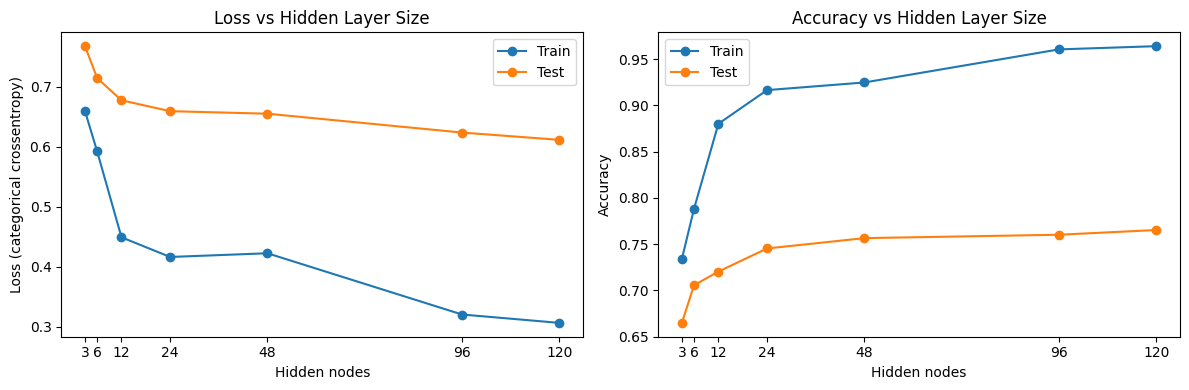

In [6]:
from matplotlib import pyplot as plt
from TIMBRE import TIMBRE

trial_phase = 2
n_folds = 5
which_fold = 0

test_inds, train_inds = helpers.test_train(data['lapID'], trial_phase, n_folds, which_fold)  # only test 1 fold per session
wLFPs, _, _ = helpers.whiten(LFPs, train_inds)

hidden_sizes = [3,6,12,24,48,96,120]  # [3, 6, 12, 24] — same as above
final_train_loss, final_val_loss = [], []
final_train_acc, final_val_acc = [], []

for n in hidden_sizes:
    print(f"Training hidden_nodes={n}")
    _, history, _ = TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=n)
    final_train_loss.append(history.history['loss'][-1])
    final_val_loss.append(history.history['val_loss'][-1])
    final_train_acc.append(history.history['accuracy'][-1])
    final_val_acc.append(history.history['val_accuracy'][-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hidden_sizes, final_train_loss, 'o-', label='Train')
ax1.plot(hidden_sizes, final_val_loss, 'o-', label='Test')
ax1.set_xlabel('Hidden nodes')
ax1.set_ylabel('Loss (categorical crossentropy)')
ax1.set_title('Loss vs Hidden Layer Size')
ax1.set_xticks(hidden_sizes)
ax1.legend()

ax2.plot(hidden_sizes, final_train_acc, 'o-', label='Train')
ax2.plot(hidden_sizes, final_val_acc, 'o-', label='Test')
ax2.set_xlabel('Hidden nodes')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs Hidden Layer Size')
ax2.set_xticks(hidden_sizes)
ax2.legend()

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
from keras import Model


hidden_nodes = 48
m24, _, _ = TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=hidden_nodes)

# ---------- Activation model ----------
# Stack real/imag the same way TIMBRE does internally
X_full = np.concatenate((np.real(wLFPs), np.imag(wLFPs)), axis=1)

# Layer 1 = amplitude layer (Lambda: sqrt(real² + imag²)) — the hidden node activations
all_activations = helpers.layer_output(wLFPs, m24, 1)  # shape: (n_timesteps, hidden_nodes)
# ---------- Behavioral variables over the full dataset ----------
fs           = 25
timestamps   = np.arange(len(data['lapID'])) / fs   # seconds from session start

arm_map      = {-1: 'junction', 0: 'arm1', 1: 'arm2', 2: 'arm3'}
position_labels = np.array([arm_map.get(int(a), 'unknown') for a in data['lapID'][:, 1]])

phase_map    = {0: 'other', 1: 'approach', 2: 'port', 3: 'departure'}
phase_labels = np.array([phase_map.get(int(p), 'other') for p in data['lapID'][:, 3]])

# speed_all and theta_amp_all are already full-dataset arrays from the previous cell
split_labels = np.full(len(data['lapID']), 'unused')
split_labels[train_inds] = 'train'
split_labels[test_inds]  = 'test'


# Running speed from x/y position (mm/s)
xy          = data['lapID'][:, 4:6].astype(float)
dxy         = np.diff(xy, axis=0, prepend=xy[[0]])
speed_all   = np.sqrt((dxy ** 2).sum(axis=1)) * 25
speed_all[np.diff(data['lapID'][:, 0].astype(int), prepend=0) != 0] = np.nan  # NaN at trial transitions

# Theta amplitude: mean instantaneous envelope across LFP channels
theta_amp_all = np.abs(LFPs).mean(axis=1)

# ---------- Build DataFrame ----------
df_dict = {
    'time':      timestamps,
    'trial':     data['lapID'][:, 0].astype(int),
    'position':  position_labels,
    'phase':     phase_labels,
    'split':     split_labels,
    'x':         data['lapID'][:, 4],
    'y':         data['lapID'][:, 5],
    'speed':     speed_all,
    'theta_amp': theta_amp_all,
}
for i in range(hidden_nodes):
    df_dict[f'node_{i+1}'] = all_activations[:, i]

df = pd.DataFrame(df_dict)

# ---------- Display ----------
print(f"Shape: {df.shape}")
display(df.tail(10))

2866/2866 ━━━━━━━━━━━━━━━━━━━━ 1s 272us/step
Shape: (91710, 57)


,time,trial,position,phase,split,x,y,speed,theta_amp,node_1,...,node_39,node_40,node_41,node_42,node_43,node_44,node_45,node_46,node_47,node_48
91700,3668.00,-1,junction,other,unused,1.558946e-68,1.924602e-68,1.107534e-66,464.829218,1.158168,...,0.846514,1.023971,1.233990,0.691628,0.436200,0.761817,0.260892,0.789109,0.555943,0.634905
91701,3668.04,-1,junction,other,unused,-1.393373e-68,-1.716093e-68,1.171827e-66,515.570589,1.360695,...,0.363057,0.903244,1.044989,1.230154,0.984262,0.825801,1.033946,0.178502,0.527682,0.782251
91702,3668.08,-1,junction,other,unused,9.110253e-69,1.118802e-68,9.133345e-67,479.237744,1.196635,...,1.207877,0.482133,0.435178,1.384385,1.269881,0.473010,1.405842,0.728418,1.220020,0.849351
91703,3668.12,-1,junction,other,unused,-3.258995e-69,-3.967740e-69,4.890650e-67,356.377160,1.640519,...,1.271363,0.819411,0.721518,0.884086,0.953936,0.853177,0.868621,1.065444,1.276939,0.618598
91704,3668.16,-1,junction,other,unused,-1.869673e-69,-2.345854e-69,5.338967e-68,435.475199,2.594683,...,0.955630,1.823802,1.661031,0.221403,0.222358,1.345828,0.363478,1.041023,0.586343,0.442861
91705,3668.20,-1,junction,other,unused,4.955222e-69,6.129755e-69,2.720468e-67,524.455711,2.711929,...,0.737994,2.151817,1.841578,1.067236,0.565939,1.091363,1.144135,1.171692,0.290251,0.504152
91706,3668.24,-1,junction,other,unused,-5.317719e-69,-6.553477e-69,4.080423e-67,431.813215,1.814888,...,0.588742,1.610824,1.352614,1.315861,0.676882,0.431782,1.243413,1.135236,0.567352,0.607632
91707,3668.28,-1,junction,other,unused,2.455565e-69,3.004825e-69,3.080027e-67,290.789063,0.841108,...,0.379285,0.940620,0.816687,1.100364,0.580458,0.075927,1.044182,0.470540,0.647899,0.494793
91708,3668.32,-1,junction,other,unused,3.798598e-69,4.709626e-69,5.425683e-68,212.796538,0.409809,...,0.274841,0.604416,0.473496,0.855361,0.691458,0.043964,0.735084,0.640524,0.588674,0.240267
91709,3668.36,-1,junction,other,unused,2.295708e-69,2.871259e-69,5.936262e-68,70.875739,0.181468,...,0.144299,0.390143,0.160566,0.285852,0.306247,0.281813,0.126647,0.144761,0.153492,0.201792


In [ ]:
from primitives import eta_sq

df_test = df[df['split'] == 'test'].copy()
df_test['speed_bin'] = pd.qcut(df_test['speed'], q=4, labels=False)
df_test['theta_bin'] = pd.qcut(df_test['theta_amp'], q=4, labels=False)
df_test['loc_bin']   = df_test['position'].map({'arm1': 0, 'arm2': 1, 'arm3': 2, 'junction': 3})

for col in node_cols:
    act = df_test[col]

    # Compute eta squared for each of the three candidate explanatory variables
    e_loc   = eta_sq(act, df_test['loc_bin'])
    e_spd   = eta_sq(act, df_test['speed_bin'])
    e_theta = eta_sq(act, df_test['theta_bin'])

    tag = 'loc' if e_loc == max(e_loc, e_spd, e_theta) else 'var'

print(node_labels)

In [ ]:
var_nodes_48 = ['node_5', 'node_8', 'node_11', 'node_16', 'node_23', 
                'node_26', 'node_27', 'node_29', 'node_35', 'node_39', 
                'node_40', 'node_46']

print(df_test[var_nodes_48 + ['theta_amp', 'speed']].corr()[
      ['theta_amp', 'speed']])

In [ ]:
print(df_test[var_nodes_48].corr())

In [ ]:
m6, _, _ = TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=6)
act6 = helpers.layer_output(wLFPs, m6, 1)  # shape: (n_timesteps, hidden_nodes)


In [ ]:
act6[:,0]

In [ ]:
from scipy.signal import welch

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i in range(6):
    node_act = act6[:,i]
    freqs, psd = welch(node_act, fs=25, nperseg=256)
    
    row, col = i // 3, i % 3
    axes[row, col].plot(freqs, psd)
    axes[row, col].set_xlabel('Frequency (Hz)')
    axes[row, col].set_ylabel('Power')
    axes[row, col].set_title(f'Node {i+1}')

plt.tight_layout()
plt.show()

In [ ]:
# Get weights of the complex projection layer
weights6 = m6.layers[0].get_weights()[0]  # shape depends on TIMBRE implementation
# weights will be complex-valued — visualize real and imaginary parts separately

fig, axes = plt.subplots(2, 6, figsize=(15, 4))
for i in range(6):
    axes[0, i].plot(weights[:, i].real)
    axes[0, i].set_title(f'Node {i+1} real')
    axes[1, i].plot(weights[:, i].imag)
    axes[1, i].set_title(f'Node {i+1} imag')

plt.tight_layout()
plt.show()

In [ ]:
m3, _, _ = TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=3)

weights3 = m3.layers[0].get_weights()[0]  

fig, axes = plt.subplots(2, 3, figsize=(15, 4))
for i in range(3):
    axes[0, i].plot(weights[:, i].real)
    axes[0, i].set_title(f'Node {i+1} real')
    axes[1, i].plot(weights[:, i].imag)
    axes[1, i].set_title(f'Node {i+1} imag')

plt.tight_layout()
plt.show()

In [ ]:
W_real, W_imag = m6.layers[0].get_weights()

n_electrodes = W_real.shape[0] // 2

for node_idx in range(6):
    # complex weight vector for this node across electrodes
    w_r = W_real[:n_electrodes, node_idx]   # real weights
    w_i = W_imag[:n_electrodes, node_idx]   # imaginary weights
    w_complex = w_r + 1j * w_i              # reconstruct complex weight
    
    print(f"Node {node_idx+1} weight magnitude range: {np.abs(w_complex).min():.3f} to {np.abs(w_complex).max():.3f}")

In [ ]:
from scipy.signal import welch

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for node_idx in range(6):
    w_r = W_real[:n_electrodes, node_idx]
    w_i = W_imag[:n_electrodes, node_idx]
    w_complex = w_r + 1j * w_i
    w_magnitude = np.abs(w_complex)
    
    # power spectrum of weight magnitudes across electrode space
    freqs, psd = welch(w_magnitude, fs=25, nperseg=min(32, n_electrodes))
    
    row, col = node_idx // 3, node_idx % 3
    axes[row, col].plot(freqs, psd)
    axes[row, col].set_xlabel('Spatial frequency')
    axes[row, col].set_ylabel('Power')
    axes[row, col].set_title(f'Node {node_idx+1}')

plt.tight_layout()
plt.show()

In [12]:
weights3.shape

(192, 3)

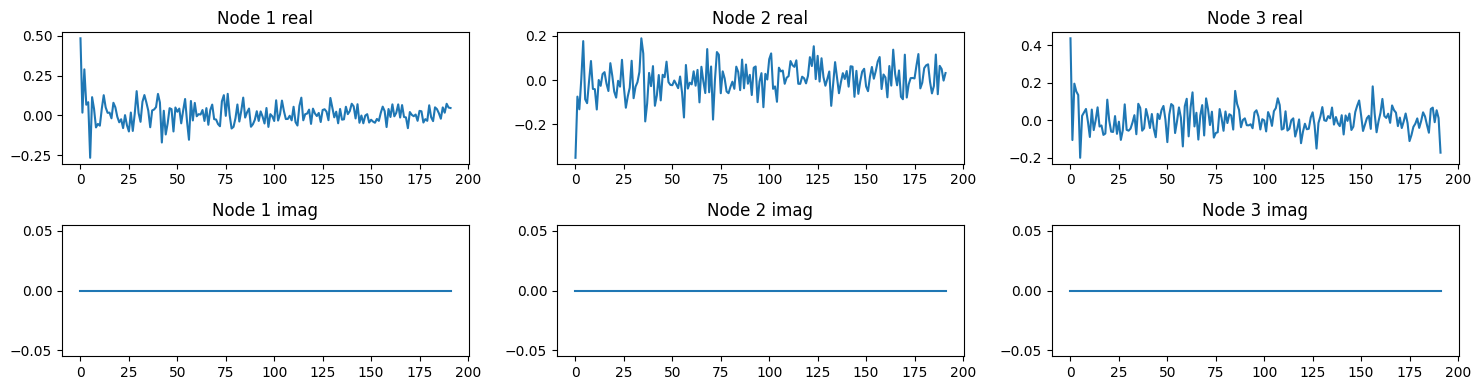

In [7]:
m3, _, _ = TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=3)

weights3 = m3.layers[0].get_weights()[0]  

fig, axes = plt.subplots(2, 3, figsize=(15, 4))
for i in range(3):
    axes[0, i].plot(weights3[:, i].real)
    axes[0, i].set_title(f'Node {i+1} real')
    axes[1, i].plot(weights3[:, i].imag)
    axes[1, i].set_title(f'Node {i+1} imag')

plt.tight_layout()
plt.show()

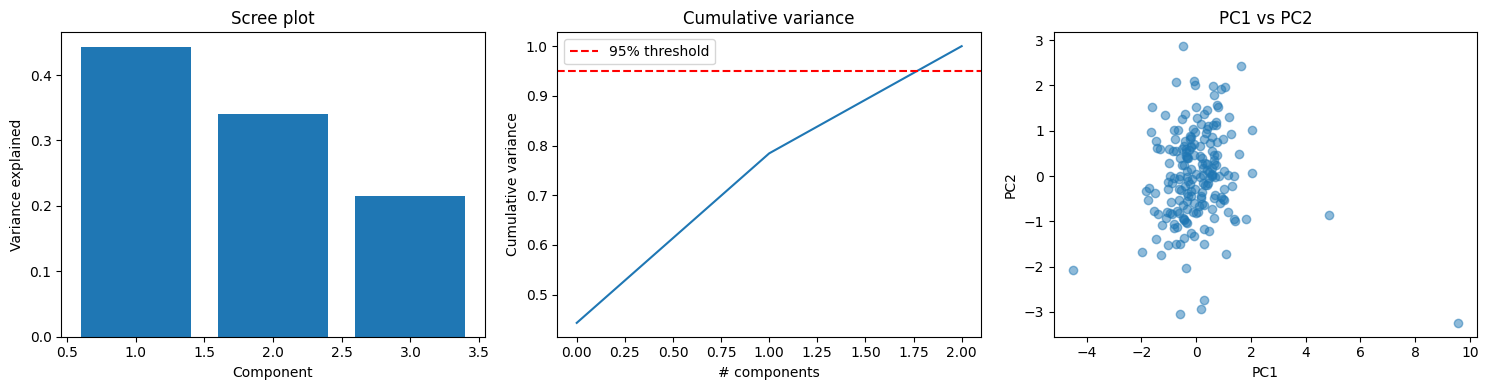

PC1: [('feature_2', np.float32(0.716)), ('feature_0', np.float32(0.683)), ('feature_1', np.float32(-0.145))]
PC2: [('feature_1', np.float32(0.948)), ('feature_0', np.float32(0.302)), ('feature_2', np.float32(-0.096))]
PC3: [('feature_2', np.float32(0.692)), ('feature_0', np.float32(-0.665)), ('feature_1', np.float32(0.282))]


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = weights3 #192,3

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()            # fit all components first to see the full picture
pca.fit(X_scaled)

# ── 3. Visualize ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 3a. Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
axes[0].set(title='Scree plot', xlabel='Component', ylabel='Variance explained')

# 3b. Cumulative variance — pick your n_components from this
axes[1].plot(np.cumsum(pca.explained_variance_ratio_))
axes[1].axhline(0.95, color='r', linestyle='--', label='95% threshold')
axes[1].set(title='Cumulative variance', xlabel='# components', ylabel='Cumulative variance')
axes[1].legend()

# 3c. Project onto first 2 PCs and scatter — just to see structure in the data
X_reduced = pca.transform(X_scaled)
axes[2].scatter(X_reduced[:, 0], X_reduced[:, 1], alpha=0.5)
axes[2].set(title='PC1 vs PC2', xlabel='PC1', ylabel='PC2')

plt.tight_layout()
plt.show()

# ── 4. Inspect what the components actually are ───────────────────────────────
# Which original features drive each component?
feature_names = [f'feature_{i}' for i in range(X.shape[1])]   # replace with real names
loadings = pca.components_[:3]   # top 3 components, shape (3, n_features)
for i, loading in enumerate(loadings):
    top = np.argsort(np.abs(loading))[::-1][:5]   # top 5 contributing features
    print(f"PC{i+1}: {[(feature_names[j], round(loading[j], 3)) for j in top]}")

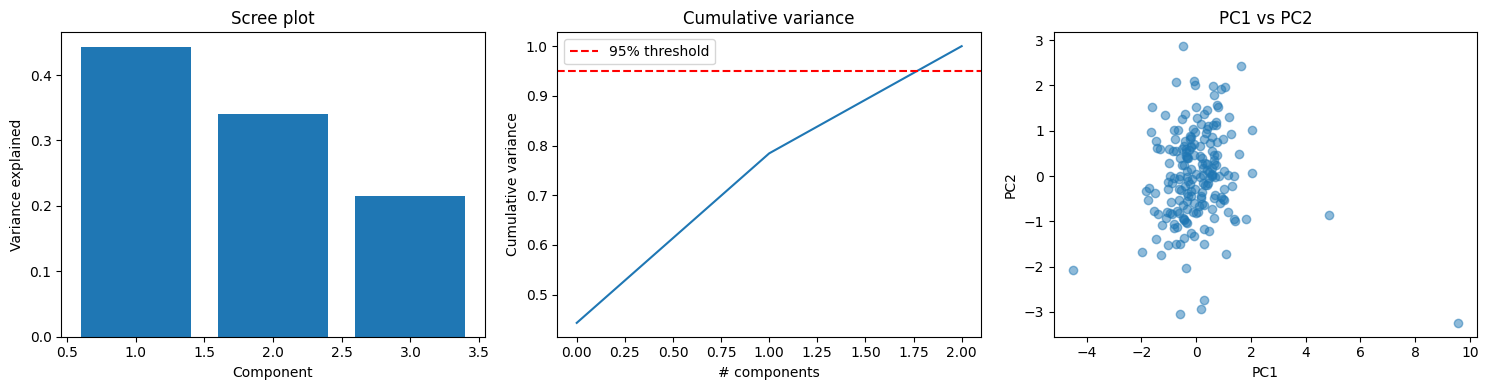

PC1: [('feature_2', np.float32(0.716)), ('feature_0', np.float32(0.683)), ('feature_1', np.float32(-0.145))]
PC2: [('feature_1', np.float32(0.948)), ('feature_0', np.float32(0.302)), ('feature_2', np.float32(-0.096))]
PC3: [('feature_2', np.float32(0.692)), ('feature_0', np.float32(-0.665)), ('feature_1', np.float32(0.282))]


In [14]:
m6, _, _ = TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=6)

weights6 = m3.layers[0].get_weights()[0]  

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = weights6 #192,6

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()            # fit all components first to see the full picture
pca.fit(X_scaled)

# ── 3. Visualize ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 3a. Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
axes[0].set(title='Scree plot', xlabel='Component', ylabel='Variance explained')

# 3b. Cumulative variance — pick your n_components from this
axes[1].plot(np.cumsum(pca.explained_variance_ratio_))
axes[1].axhline(0.95, color='r', linestyle='--', label='95% threshold')
axes[1].set(title='Cumulative variance', xlabel='# components', ylabel='Cumulative variance')
axes[1].legend()

# 3c. Project onto first 2 PCs and scatter — just to see structure in the data
X_reduced = pca.transform(X_scaled)
axes[2].scatter(X_reduced[:, 0], X_reduced[:, 1], alpha=0.5)
axes[2].set(title='PC1 vs PC2', xlabel='PC1', ylabel='PC2')

plt.tight_layout()
plt.show()

# ── 4. Inspect what the components actually are ───────────────────────────────
# Which original features drive each component?
feature_names = [f'feature_{i}' for i in range(X.shape[1])]   # replace with real names
loadings = pca.components_[:3]   # top 3 components, shape (3, n_features)
for i, loading in enumerate(loadings):
    top = np.argsort(np.abs(loading))[::-1][:5]   # top 5 contributing features
    print(f"PC{i+1}: {[(feature_names[j], round(loading[j], 3)) for j in top]}")